# Data Understanding — HUPA-UCM Diabetes Dataset

### 1. Objective

The goal of this notebook is to understand the structure, quality, and characteristics of the HUPA-UCM Diabetes Dataset before performing cleaning, feature engineering, and advanced analysis.

This notebook focuses on:

- understanding dataset structure
- identifying available variables
- checking data consistency
- validating timestamps
- understanding patient coverage
- performing initial exploratory summaries
- identifying possible data quality issues

A strong data understanding phase helps ensure that future analysis, statistical reasoning, visualizations, and predictive models are reliable and medically meaningful.

## 2. Import Required Libraries

We import libraries required for:

- data manipulation
- visualization
- file handling
- statistical summaries

These libraries form the foundation for the rest of the project.

### Why This Step Is Important

Importing libraries at the beginning keeps the notebook organized and ensures reproducibility.

### Consequence If Skipped

Without properly importing libraries:

- code cells may fail unexpectedly
- visualizations may not render
- preprocessing and analysis workflows become inconsistent

In [1]:
# ================================
# Core Python Libraries
# ================================

import os
import glob

# ================================
# Data Manipulation
# ================================

import pandas as pd
import numpy as np

# ================================
# Visualization Libraries
# ================================

import matplotlib.pyplot as plt
import seaborn as sns

# ================================
# Display Settings
# ================================

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


## 3. Universal Visualization Styling

This section defines a universal visualization theme that will automatically apply to all charts throughout the notebook.

The objective is to create:

- professional-looking charts
- consistent visual appearance
- vibrant readable colors
- cleaner storytelling visuals
- presentation-ready outputs

### Why This Step Is Important

Consistent visualization styling improves:

- readability
- professionalism
- insight communication
- dashboard consistency
- stakeholder presentation quality

### Consequence If Skipped

If visualization styling is not standardized:

- charts may look inconsistent
- colors may become repetitive
- presentations may appear unprofessional
- interpretation becomes harder

In [2]:
# ============================================
# Universal Chart Styling Configuration
# ============================================

# Seaborn theme
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

# Vibrant custom palette
custom_palette = [
    "#FF6B6B",  # coral red
    "#4ECDC4",  # teal
    "#556270",  # dark blue-gray
    "#C7F464",  # lime
    "#FFA600",  # orange
    "#8E44AD",  # purple
    "#2ECC71",  # green
    "#E67E22",  # carrot
    "#3498DB",  # blue
    "#E91E63"   # pink
]

sns.set_palette(custom_palette)

# Matplotlib settings
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11
plt.rcParams["legend.fontsize"] = 11

print("Universal chart styling applied successfully.")

Universal chart styling applied successfully.


## 4. Define Dataset Path

This step identifies the location of the raw patient CSV files.

The dataset consists of multiple patient-level files, each containing glucose and activity-related measurements.

### Why This Step Is Important

Explicitly defining paths:

- improves reproducibility
- avoids hardcoded file confusion
- makes project structure scalable

### Consequence If Skipped

Without organized path management:

- notebooks become difficult to maintain
- portability becomes poor
- file loading errors increase

In [3]:
os.listdir("../data/raw")

['HUPA-UC Diabetes Dataset']

In [4]:
# ============================================
# Define Dataset Paths
# ============================================

DATA_DIR = "../data/raw/HUPA-UC Diabetes Dataset"

print("Dataset directory defined successfully.")
print(DATA_DIR)

Dataset directory defined successfully.
../data/raw/HUPA-UC Diabetes Dataset


## 5. List Files
### Inspect Raw Dataset Files

This step checks whether all patient files are available and confirms that the dataset was loaded correctly.

### Why This Step Is Important

This helps verify:

- dataset extraction success
- file naming consistency
- patient file availability

### Consequence If Skipped

If files are missing or corrupted:

- later preprocessing may fail
- patient-level analysis may become incomplete

In [5]:
# ============================================
# List Files in Raw Data Folder
# ============================================

all_files = os.listdir(DATA_DIR)

print("Total files found:", len(all_files))
print()

all_files[:10]

Total files found: 27



['HUPA0001P.csv',
 'HUPA0002P.csv',
 'HUPA0003P.csv',
 'HUPA0004P.csv',
 'HUPA0005P.csv',
 'HUPA0006P.csv',
 'HUPA0007P.csv',
 'HUPA0009P.csv',
 'HUPA0010P.csv',
 'HUPA0011P.csv']

## 6. Load Sample Patient Dataset

Before combining all patient files, we inspect a single patient file to understand:

- available columns
- data types
- time format
- measurement structure

### Why This Step Is Important

Understanding one file first helps validate assumptions before performing large-scale dataset merging.

### Consequence If Skipped

Combining files blindly may introduce:

- inconsistent schemas
- hidden formatting problems
- invalid assumptions

In [6]:
# ============================================
# Load Sample Patient File
# ============================================

sample_file = os.path.join(DATA_DIR, "HUPA0001P.csv")

df_sample = pd.read_csv(sample_file, sep=";")

print("Sample dataset shape:", df_sample.shape)

Sample dataset shape: (4096, 8)


## 7. Inspect Dataset Structure

We now inspect:

- columns
- data types
- missing values
- memory usage

### Why This Step Is Important

This step provides an initial understanding of:

- numerical variables
- categorical variables
- possible preprocessing requirements

### Consequence If Skipped

Without understanding structure:

- incorrect preprocessing decisions may occur
- analysis logic may become invalid

In [7]:
# ============================================
# Dataset Structure
# ============================================

df_sample.info()

<class 'pandas.DataFrame'>
RangeIndex: 4096 entries, 0 to 4095
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   time                    4096 non-null   str    
 1   glucose                 4096 non-null   float64
 2   calories                4096 non-null   float64
 3   heart_rate              4096 non-null   float64
 4   steps                   4096 non-null   float64
 5   basal_rate              4096 non-null   float64
 6   bolus_volume_delivered  4096 non-null   float64
 7   carb_input              4096 non-null   float64
dtypes: float64(7), str(1)
memory usage: 332.1 KB


## 8. Preview Dataset

We inspect the first few rows to understand:

- glucose measurements
- timestamps
- activity variables
- insulin variables
- carbohydrate records

### Why This Step Is Important

Visual inspection often reveals issues not visible through summaries alone.

### Consequence If Skipped

Potential formatting or logic issues may remain unnoticed.

In [8]:
# ============================================
# Preview Dataset
# ============================================

df_sample.head()

,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input
0,2018-06-13T18:40:00,332.0,6.3595,82.322835,34.0,0.091667,0.0,0.0
1,2018-06-13T18:45:00,326.0,7.7280,83.740157,0.0,0.091667,0.0,0.0
2,2018-06-13T18:50:00,330.0,4.7495,80.525180,0.0,0.091667,0.0,0.0
3,2018-06-13T18:55:00,324.0,6.3595,89.129032,20.0,0.091667,0.0,0.0
4,2018-06-13T19:00:00,306.0,5.1520,92.495652,0.0,0.075000,0.0,0.0


### Statistical Summary

We calculate summary statistics for numerical variables.

This helps identify:

- ranges
- unusual values
- possible outliers
- overall glucose behavior

### Why This Step Is Important

Statistical summaries help establish baseline characteristics of the dataset.

### Consequence If Skipped

Outliers and unusual distributions may remain undetected.

In [9]:
# ============================================
# Statistical Summary
# ============================================

df_sample.describe()

,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input
count,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000,4096.000000
mean,181.443726,5.920327,80.827004,19.467529,0.049675,0.038477,0.029541
std,70.644633,3.460342,12.929865,57.332804,0.022216,0.344373,0.310549
min,40.000000,4.025000,53.462278,0.000000,0.000000,0.000000,0.000000
25%,131.000000,4.025000,69.755759,0.000000,0.037500,0.000000,0.000000
50%,165.666667,4.186000,81.007930,0.000000,0.041667,0.000000,0.000000
75%,222.000000,6.440000,89.834402,8.000000,0.070833,0.000000,0.000000
max,444.000000,37.513000,167.322581,621.000000,0.091667,5.200000,4.000000


## 10. Check All CSV Files

In [10]:
# ============================================
# Get All CSV Files Automatically
# ============================================

csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))

print("Total CSV files found:", len(csv_files))

csv_files[:5]

Total CSV files found: 26


['../data/raw/HUPA-UC Diabetes Dataset\\HUPA0001P.csv',
 '../data/raw/HUPA-UC Diabetes Dataset\\HUPA0002P.csv',
 '../data/raw/HUPA-UC Diabetes Dataset\\HUPA0003P.csv',
 '../data/raw/HUPA-UC Diabetes Dataset\\HUPA0004P.csv',
 '../data/raw/HUPA-UC Diabetes Dataset\\HUPA0005P.csv']

In [11]:
# Load first patient file dynamically

sample_file = csv_files[0]

df_sample = pd.read_csv(sample_file, sep=";")

print("Loaded file:", sample_file)
print("Shape:", df_sample.shape)

Loaded file: ../data/raw/HUPA-UC Diabetes Dataset\HUPA0001P.csv
Shape: (4096, 8)


## Identify All Patient CSV Files

Now that the dataset path is correct, we identify all patient-level CSV files.

### Why This Step Is Important

The dataset contains multiple patient files. Before combining them, we need to confirm how many patient files exist and make sure we do not accidentally include demographic or unrelated files.

### Consequence If Skipped

If we combine files blindly, we may accidentally include non-patient files, create wrong columns, or corrupt the analysis dataset.

In [12]:
# Get all CSV files in the dataset folder
csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))

# Keep only patient files that start with HUPA and end with P.csv
patient_files = [
    file for file in csv_files
    if os.path.basename(file).startswith("HUPA") and os.path.basename(file).endswith("P.csv")
]

print("Total CSV files found:", len(csv_files))
print("Total patient files found:", len(patient_files))

patient_files[:5]

Total CSV files found: 26
Total patient files found: 25


['../data/raw/HUPA-UC Diabetes Dataset\\HUPA0001P.csv',
 '../data/raw/HUPA-UC Diabetes Dataset\\HUPA0002P.csv',
 '../data/raw/HUPA-UC Diabetes Dataset\\HUPA0003P.csv',
 '../data/raw/HUPA-UC Diabetes Dataset\\HUPA0004P.csv',
 '../data/raw/HUPA-UC Diabetes Dataset\\HUPA0005P.csv']

## 12. Validate Column Consistency Across Patient Files

Before combining files, we check whether all patient files have the same columns.

### Why This Step Is Important

Combining datasets only makes sense if the files have a consistent structure. Since each file represents a patient, column consistency ensures that glucose, insulin, activity, and food variables are aligned correctly.

### Consequence If Skipped

If one file has missing or extra columns, the combined dataset may contain incorrect missing values or misleading analysis results.

In [13]:
# Check column consistency across all patient files
column_check = {}

for file in patient_files:
    temp_df = pd.read_csv(file, sep=";", nrows=5)
    column_check[os.path.basename(file)] = list(temp_df.columns)

# Convert to DataFrame for easier review
column_check_df = pd.DataFrame.from_dict(column_check, orient="index")

column_check_df.head()

,0,1,2,3,4,5,6,7
HUPA0001P.csv,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input
HUPA0002P.csv,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input
HUPA0003P.csv,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input
HUPA0004P.csv,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input
HUPA0005P.csv,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input


In [14]:
# Count unique column structures
unique_column_sets = set(tuple(cols) for cols in column_check.values())

print("Number of unique column structures:", len(unique_column_sets))

for cols in unique_column_sets:
    print(cols)

Number of unique column structures: 1
('time', 'glucose', 'calories', 'heart_rate', 'steps', 'basal_rate', 'bolus_volume_delivered', 'carb_input')


## 13. Combine Patient Files

Each patient file contains time-series health measurements. We combine all patient files into one dataset and create a patient_id column from the file name.

### Why This Step Is Important

A combined dataset allows us to perform population-level and patient-level analysis.

This supports questions such as:

- Which patients have higher average glucose?
- How does glucose vary across time?
- Are insulin, activity, and carbohydrate intake related to glucose?
- Are some patients more likely to experience high or low glucose?

### Consequence If Skipped

Without combining files, we would only analyze one patient at a time and miss broader patterns across the full dataset.

In [15]:
# Combine all patient CSV files into one DataFrame
combined_data = []

for file in patient_files:
    temp_df = pd.read_csv(file, sep=";")
    
    # Extract patient ID from file name
    patient_id = os.path.basename(file).replace(".csv", "")
    
    # Add patient ID column
    temp_df["patient_id"] = patient_id
    
    # Append to list
    combined_data.append(temp_df)

df = pd.concat(combined_data, ignore_index=True)

print("Combined dataset shape:", df.shape)
df.head()

Combined dataset shape: (309392, 9)


,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input,patient_id
0,2018-06-13T18:40:00,332.0,6.3595,82.322835,34.0,0.091667,0.0,0.0,HUPA0001P
1,2018-06-13T18:45:00,326.0,7.7280,83.740157,0.0,0.091667,0.0,0.0,HUPA0001P
2,2018-06-13T18:50:00,330.0,4.7495,80.525180,0.0,0.091667,0.0,0.0,HUPA0001P
3,2018-06-13T18:55:00,324.0,6.3595,89.129032,20.0,0.091667,0.0,0.0,HUPA0001P
4,2018-06-13T19:00:00,306.0,5.1520,92.495652,0.0,0.075000,0.0,0.0,HUPA0001P


## 14. Inspect Combined Dataset

After combining patient files, we inspect the complete dataset.

### Why This Step Is Important

This confirms that the merge worked correctly and that patient_id was added successfully.

### Consequence If Skipped

Errors during merging may go unnoticed and affect every future notebook.

In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 309392 entries, 0 to 309391
Data columns (total 9 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   time                    309392 non-null  str    
 1   glucose                 309392 non-null  float64
 2   calories                309392 non-null  float64
 3   heart_rate              309392 non-null  float64
 4   steps                   309392 non-null  float64
 5   basal_rate              309392 non-null  float64
 6   bolus_volume_delivered  309392 non-null  float64
 7   carb_input              309392 non-null  float64
 8   patient_id              309392 non-null  str    
dtypes: float64(7), str(2)
memory usage: 29.5 MB


In [17]:
df.head()

,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input,patient_id
0,2018-06-13T18:40:00,332.0,6.3595,82.322835,34.0,0.091667,0.0,0.0,HUPA0001P
1,2018-06-13T18:45:00,326.0,7.7280,83.740157,0.0,0.091667,0.0,0.0,HUPA0001P
2,2018-06-13T18:50:00,330.0,4.7495,80.525180,0.0,0.091667,0.0,0.0,HUPA0001P
3,2018-06-13T18:55:00,324.0,6.3595,89.129032,20.0,0.091667,0.0,0.0,HUPA0001P
4,2018-06-13T19:00:00,306.0,5.1520,92.495652,0.0,0.075000,0.0,0.0,HUPA0001P


In [18]:
df.tail()

,time,glucose,calories,heart_rate,steps,basal_rate,bolus_volume_delivered,carb_input,patient_id
309387,2022-05-18T11:55:00,109.333333,10.79280,104.171171,0.0,0.0,0.0,0.0,HUPA0028P
309388,2022-05-18T12:00:00,114.000000,9.80346,103.442623,0.0,0.0,0.0,0.0,HUPA0028P
309389,2022-05-18T12:05:00,118.666667,5.66622,95.542857,0.0,0.0,0.0,0.0,HUPA0028P
309390,2022-05-18T12:10:00,123.333333,5.57628,91.381356,0.0,0.0,0.0,0.0,HUPA0028P
309391,2022-05-18T12:15:00,128.000000,5.57628,99.257812,0.0,0.0,0.0,0.0,HUPA0028P


## 15. Check Patient Count

The dataset description says the data was collected from 25 people with Type 1 Diabetes. We verify that the combined dataset includes the expected number of patients.

### Why This Step Is Important

Patient count validation confirms dataset completeness.

### Consequence If Skipped

If patients are missing, conclusions may be incomplete or biased.

In [19]:
patient_count = df["patient_id"].nunique()

print("Number of unique patients:", patient_count)
print("Patient IDs:")
print(sorted(df["patient_id"].unique()))

Number of unique patients: 25
Patient IDs:
['HUPA0001P', 'HUPA0002P', 'HUPA0003P', 'HUPA0004P', 'HUPA0005P', 'HUPA0006P', 'HUPA0007P', 'HUPA0009P', 'HUPA0010P', 'HUPA0011P', 'HUPA0014P', 'HUPA0015P', 'HUPA0016P', 'HUPA0017P', 'HUPA0018P', 'HUPA0019P', 'HUPA0020P', 'HUPA0021P', 'HUPA0022P', 'HUPA0023P', 'HUPA0024P', 'HUPA0025P', 'HUPA0026P', 'HUPA0027P', 'HUPA0028P']


## 16. Save Combined Raw Dataset

We save the combined dataset into the processed folder.

This file is not fully cleaned yet. It is a combined version of the raw patient files and will be used as input for the cleaning notebook.

### Why This Step Is Important

Saving an intermediate dataset improves workflow organization and prevents repeated loading and merging.

### Consequence If Skipped

Every future notebook would need to repeat the combining process, increasing runtime and chances of mistakes.

In [20]:
# Save combined dataset
output_path = "../data/processed/combined_raw_patient_data.csv"

df.to_csv(output_path, index=False)

print("Combined raw dataset saved successfully.")
print("File path:", output_path)

Combined raw dataset saved successfully.
File path: ../data/processed/combined_raw_patient_data.csv


## 17. Check Missing Values

### Missing Value Analysis

We now inspect missing values across all variables.

Missing values are common in healthcare and wearable-device datasets because:

- sensors may disconnect
- patients may skip entries
- devices may fail temporarily
- measurements may not always be recorded

### Why This Step Is Important

Understanding missingness helps determine:

- which columns require cleaning
- whether imputation is needed
- whether variables are reliable enough for analysis

### Consequence If Skipped

If missing values are ignored:

- statistical summaries may become misleading
- charts may become inaccurate
- predictive models may fail
- healthcare conclusions may become unreliable

In [21]:
# ============================================
# Missing Value Analysis
# ============================================

missing_values = df.isnull().sum()

missing_percent = (
    df.isnull().mean() * 100
).round(2)

missing_df = pd.DataFrame({
    "missing_count": missing_values,
    "missing_percentage": missing_percent
})

missing_df.sort_values(
    by="missing_percentage",
    ascending=False
)

,missing_count,missing_percentage
time,0,0.0
glucose,0,0.0
calories,0,0.0
heart_rate,0,0.0
steps,0,0.0
basal_rate,0,0.0
bolus_volume_delivered,0,0.0
carb_input,0,0.0
patient_id,0,0.0


## 18. Visualize Missing Values

Visualization helps identify which variables contain the highest proportion of missing data.

### Why This Step Is Important

Charts make missing-data patterns easier to identify compared to raw tables.

### Consequence If Skipped

Patterns in missingness may remain hidden and affect future analysis quality.

In [22]:
# ============================================
# Missing Value Visualization
# ============================================

missing_plot = missing_df.reset_index()

missing_plot.columns = [
    "column",
    "missing_count",
    "missing_percentage"
]

# Keep only columns with missing values
missing_plot = missing_plot[
    missing_plot["missing_percentage"] > 0
]

if len(missing_plot) > 0:

    plt.figure(figsize=(12, 6))

    sns.barplot(
        data=missing_plot,
        x="column",
        y="missing_percentage"
    )

    plt.title("Missing Value Percentage by Column")
    plt.xlabel("Columns")
    plt.ylabel("Missing Percentage")

    plt.xticks(rotation=45)

    plt.show()

else:
    print("No missing values detected in the dataset.")

No missing values detected in the dataset.


### Interpretation of Missing Value Analysis

The dataset currently shows no missing values across the analyzed variables.

This is beneficial because:

- glucose trends remain continuous
- statistical summaries remain reliable
- temporal analysis becomes easier
- predictive workflows become more stable

Since no missingness was detected, no immediate imputation strategy is required at this stage.

However, missing value analysis was still an essential validation step because healthcare and wearable-device datasets commonly contain sensor interruptions and incomplete records.

In [23]:
df.columns

Index(['time', 'glucose', 'calories', 'heart_rate', 'steps', 'basal_rate',
       'bolus_volume_delivered', 'carb_input', 'patient_id'],
      dtype='str')

## 19. Convert Time Column to Datetime

The time column is currently stored as text and must be converted into datetime format.

### Why This Step Is Important

Datetime conversion enables:

- time-series analysis
- hourly trends
- daily trends
- rolling calculations
- lag feature creation
- glucose trend analysis

### Consequence If Skipped

Without datetime conversion:

- time-based analysis becomes impossible
- sorting may become incorrect
- visualizations may be misleading

In [24]:
# ============================================
# Convert Time Column
# ============================================

df["time"] = pd.to_datetime(df["time"])
df = df.sort_values(
    by=["patient_id", "time"]
)
print("Datetime conversion successful.")
print(df["time"].dtype)

Datetime conversion successful.
datetime64[us]


### Sort Dataset Chronologically

The dataset is sorted by patient and timestamp to preserve proper time-series order.

Why This Step Is Important

Time-series healthcare data must remain chronologically ordered for:

- trend analysis
- rolling statistics
- lag features
- glucose forecasting

Consequence If Skipped

Future temporal analysis may become inaccurate because events may appear out of order.

## 20. Dataset Time Range

We inspect the earliest and latest timestamps in the dataset.

### Why This Step Is Important

Understanding time coverage helps determine:

- recording duration
- observation periods
- consistency across patients

### Consequence If Skipped

We may incorrectly assume the dataset covers longer or shorter durations than it actually does.

In [25]:
# ============================================
# Dataset Time Range
# ============================================

print("Earliest timestamp:")
print(df["time"].min())

print()

print("Latest timestamp:")
print(df["time"].max())

Earliest timestamp:
2018-06-13 18:40:00

Latest timestamp:
2022-05-18 12:15:00


## 21. Create Basic Time Features

We extract useful time-based features from the timestamp.

These include:

- hour
- day
- day of week
- date

### Why This Step Is Important

Time-based variables are critical in glucose analysis because:

- glucose changes throughout the day
- meals happen at different times
- insulin patterns vary by schedule
- activity levels change across days

### Consequence If Skipped

Important temporal patterns may remain hidden.

In [26]:
# ============================================
# Time-Based Features
# ============================================

df["hour"] = df["time"].dt.hour

df["day"] = df["time"].dt.day

df["day_of_week"] = df["time"].dt.day_name()

df["date"] = df["time"].dt.date

print("Time features created successfully.")

Time features created successfully.


## 22. Glucose Summary Statistics

Glucose is the primary healthcare variable in this project.

We inspect:

- average glucose
- minimum glucose
- maximum glucose
- variability

### Why This Step Is Important

Understanding glucose behavior helps establish:

- baseline patient conditions
- potential hyperglycemia
- potential hypoglycemia
- variability severity

### Consequence If Skipped

Future analysis may lack clinical context.

In [27]:
# ============================================
# Glucose Summary Statistics
# ============================================

df["glucose"].describe()

count    309392.000000
mean        141.425051
std          57.085587
min          40.000000
25%          99.666667
50%         132.000000
75%         173.000000
max         444.000000
Name: glucose, dtype: float64

## 23. Glucose Distribution

We visualize the overall distribution of glucose values.

### Why This Step Is Important

Distribution analysis helps identify:

- skewness
- abnormal ranges
- possible outliers
- dominant glucose ranges

### Consequence If Skipped

Extreme glucose behavior may remain hidden.

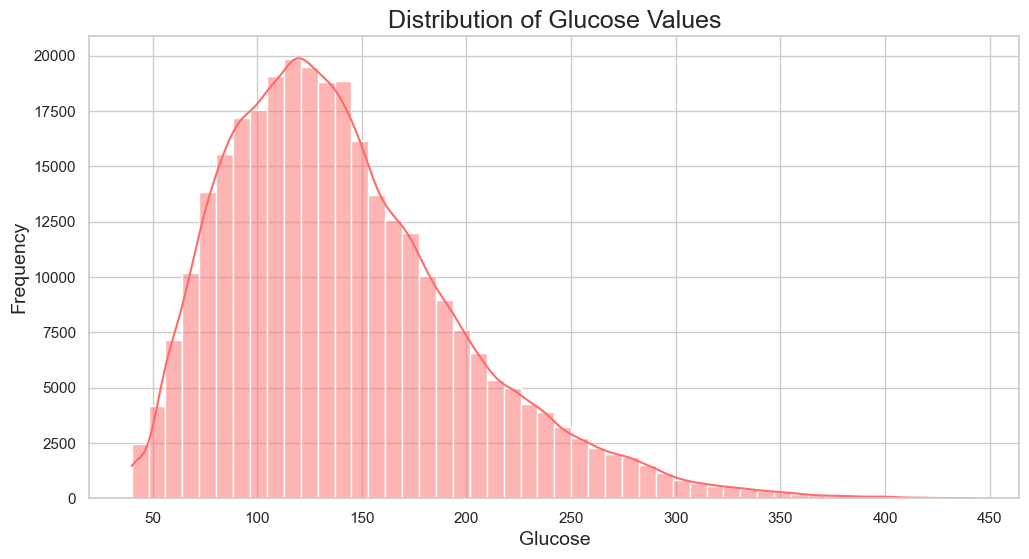

In [28]:
# ============================================
# Glucose Distribution Plot
# ============================================

plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="glucose",
    bins=50,
    kde=True
)

plt.title("Distribution of Glucose Values")
plt.xlabel("Glucose")
plt.ylabel("Frequency")

plt.show()

## 24. Patient-Level Average Glucose

We compare average glucose levels across patients.

### Why This Step Is Important

Patient-level comparison helps identify:

- glucose variability between individuals
- patients with consistently high glucose
- patients with tighter glucose control

### Consequence If Skipped

Population-level summaries may hide patient-specific trends.

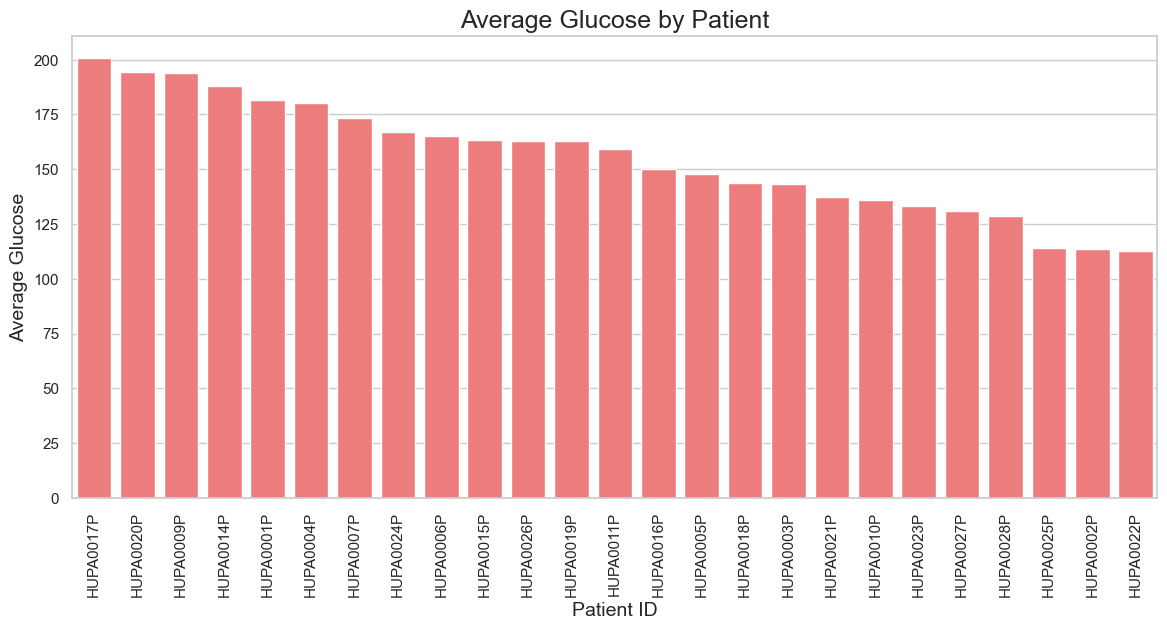

In [29]:
# ============================================
# Patient Average Glucose
# ============================================

patient_glucose = (
    df.groupby("patient_id")["glucose"]
    .mean()
    .sort_values(ascending=False)
)

patient_glucose_df = patient_glucose.reset_index()

patient_glucose_df.columns = [
    "patient_id",
    "avg_glucose"
]

plt.figure(figsize=(14, 6))

sns.barplot(
    data=patient_glucose_df,
    x="patient_id",
    y="avg_glucose"
)

plt.title("Average Glucose by Patient")
plt.xlabel("Patient ID")
plt.ylabel("Average Glucose")

plt.xticks(rotation=90)

plt.show()

## 25. Save Updated Understanding Dataset

In [30]:
# ============================================
# Save Updated Dataset
# ============================================

output_path = "../data/processed/data_understanding_dataset.csv"

df.to_csv(output_path, index=False)

print("Dataset saved successfully.")

Dataset saved successfully.


## 26. Key Findings from Data Understanding

### Observations

1. The dataset contains multiple patient-level time-series files.
2. Glucose measurements show significant variability across patients.
3. Some variables contain missing values that will require preprocessing.
4. Time-series structure appears suitable for temporal analysis.
5. Glucose distributions indicate both low and high glucose events.
6. Patient-level differences suggest individualized glucose behavior.

### Planned Next Steps

The next notebook will focus on:

- missing value handling
- duplicate detection
- time-series validation
- outlier analysis
- glucose categorization
- feature engineering
- rolling statistics
- lag feature creation